In [1]:
#!pip install dataframe-image
!pip install --upgrade setuptools packaging
!pip install -U -e ..

In [2]:
import os
import time
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
from statsmodels.tsa.api import ARIMA, ExponentialSmoothing
import torch
from gym import spaces
import dataframe_image as dfi

import warnings

from blockhouse_ml.utils.macro_model import MetaLearner
from blockhouse_ml.utils.data_handler import DataProcessor, InferenceDataHandler
from blockhouse_ml.utils.macro_model_utils import MacroTraderModel
from blockhouse_ml.utils import fetch_merge_data
from blockhouse_ml.utils.env import TradingEnvironment, CustomTradingEnvironment
import blockhouse_ml.utils.benchmark_utils as benchmarks 

c:\Users\yashv\miniconda3\envs\MLProj\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-08-25 09:52:49,295	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-08-25 09:52:49,495	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
warnings.filterwarnings("ignore")

In [4]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
'''
Because of this error:
 [error] Disposing session as kernel process died ExitCode: 3, Reason: OMP: Error #15: Initializing libiomp5md.dll, but found libomp140.x86_64.dll already initialized.
OMP: Hint This means that multiple copies of the OpenMP runtime have been linked into the program. That is dangerous, since it can degrade performance or cause incorrect results. The best thing to do is to ensure that only a single OpenMP runtime is linked into the process, e.g. by avoiding static linking of the OpenMP runtime in any library. As an unsafe, unsupported, undocumented workaround you can set the environment variable KMP_DUPLICATE_LIB_OK=TRUE to allow the program to continue to execute, but that may cause crashes or silently produce incorrect results. For more information, please see http://www.intel.com/software/products/support/.
'''

'\nBecause of this error:\n [error] Disposing session as kernel process died ExitCode: 3, Reason: OMP: Error #15: Initializing libiomp5md.dll, but found libomp140.x86_64.dll already initialized.\nOMP: Hint This means that multiple copies of the OpenMP runtime have been linked into the program. That is dangerous, since it can degrade performance or cause incorrect results. The best thing to do is to ensure that only a single OpenMP runtime is linked into the process, e.g. by avoiding static linking of the OpenMP runtime in any library. As an unsafe, unsupported, undocumented workaround you can set the environment variable KMP_DUPLICATE_LIB_OK=TRUE to allow the program to continue to execute, but that may cause crashes or silently produce incorrect results. For more information, please see http://www.intel.com/software/products/support/.\n'

In [5]:
# Initialize the model directory, where the models will be saved
UNET_MODEL_DIR = 'Models'
os.makedirs(UNET_MODEL_DIR, exist_ok=True)

TAB_MODEL_DIR = 'TabModels'
os.makedirs(TAB_MODEL_DIR, exist_ok=True)

# Initialize the data directory, where the data will be stored
data_dir = 'Data'
os.makedirs(data_dir, exist_ok=True)

# Initialize the MetaLearner
meta = MetaLearner()

# Initialize the MacroTraderModel
macro_trader_unet = MacroTraderModel(UNET_MODEL_DIR)

macro_trader_tab = MacroTraderModel(TAB_MODEL_DIR)

# Initialize the data processor
data_processor = DataProcessor()

# Inference data handler
inference_data_handler = InferenceDataHandler()

# Define the forecast steps
forecast_steps = {
    'open': (360, '1T'),
    'high': (360, '1T'),
    'low': (360, '1T'),
    'close': (360, '1T'),
    'volatility': (360, '1T'),
    'volume': (360, '1T'),
    'transaction_cost': (360, '1T')
}



# Define the start and end dates
start_time = '2024-07-01'
end_time = '2024-08-16'

# List of Companies based on Market Capitalization
large_cap_companies = []#['AAPL', 'CSCO', 'MCD', 'IBM', 'AMZN', 'TSLA', 'PFE', 'MS','MSFT','NVDA']
mid_cap_companies = [] #['AEG', 'NICE', 'NLY', 'ONTO', 'PSN', 'SAIA', 'OWL','PNW','TWLO','HAS']
small_cap_companies = ['NVAX','AMC','WOLF','IREN','SEDG', 'UPWK','FSLY','BMBL','ARRY']

In [6]:
def get_data(data_dir, ticker, start_time, end_time):
     ## Fetch and process the data and save it to the data directory, if it doesn't exist
    processed_filename = f'{data_dir}/processed_data_{ticker}_{start_time}_{end_time}.csv'
    if os.path.exists(processed_filename):
        processed_data = pd.read_csv(processed_filename)
    else:
        filename = f'{data_dir}/merged_data_{ticker}_{start_time}_{end_time}.csv'
        if os.path.exists(filename):
            data = pd.read_csv(filename)
        else:
            data = fetch_merge_data.fetch_and_merge_data(ticker,start_date=start_time,end_date=end_time,save_dir =data_dir)

        processed_data = data_processor.process_data(data, forecast_steps,n_jobs=4)
        processed_data.to_csv(processed_filename)

    return processed_data

In [7]:
from collections import defaultdict
results_twap = defaultdict() # Dictionary to store results from TWAP, VWAP and unet_trans model
results_unet = defaultdict()
results_tab = defaultdict()
results_vwap = defaultdict()

IS_twaps = defaultdict() # Dictionary to store IS from TWAP model for each ticker
IS_unets = defaultdict()
IS_tabs = defaultdict()
IS_vwaps = defaultdict()

for companies in [large_cap_companies, mid_cap_companies, small_cap_companies]:
    for ticker in companies:
        processed_data = get_data(data_dir, ticker, start_time, end_time)
        # Only need test data for testing
        test_data = processed_data[int(len(processed_data) * 0.8):]
        test_data = test_data.loc[test_data['bid_price'] > 0]
        print("Testing Model for ", ticker)
        market_cap_int = fetch_merge_data.get_market_cap(ticker)
        market_cap = meta.classify_market_cap(market_cap_int)
        timeframe=500
        inventory=10000
        # for transaction_size in [9, 99, 499, 1999, 10000]:
        scenario = meta.classify_scenario(inventory)
        #     print("Training Model for ticker: {} Transaction Size: {} Market Cap: {}".format(ticker, scenerio, market_cap))
        #     training_params['tb_log_name'] =f'{log_dir}/{ticker}_{scenerio}_{market_cap}'
        print("------------------------")
        print("Testing on ", ticker)

        # print("------------------------")
        
        print("Testing on TWAP | ",end="")
        twap_trades = benchmarks.get_twap_trades(test_data, inventory, timeframe)
        # print("TWAP Trades: ", len(twap_trades), twap_trades.head())
        slippage , market, liquidity, tc, twap_rew, IS_twap_per_ticker = benchmarks.simulate_strategy(twap_trades, data=test_data,preferred_timeframe=timeframe)
        results_twap[ticker] = (slippage,market,liquidity,tc, twap_rew)
        IS_twaps[ticker] = IS_twap_per_ticker
        print("slippage on TWAP: ", sum(slippage)/len(slippage))
        print("IS on TWAP: ", IS_twap_per_ticker.mean())
        # print("------------------------")
        
        print("Testing on VWAP | ",end="")
        vwap_trades = benchmarks.get_vwap_trades(test_data, inventory, timeframe)
        slippage , market, liquidity, tc, vwap_rew, IS_vwap_per_ticker = benchmarks.simulate_strategy(vwap_trades, data=test_data,preferred_timeframe=timeframe)
        results_vwap[ticker] = (slippage,market,liquidity,tc, vwap_rew)
        IS_vwaps[ticker] = IS_vwap_per_ticker
        print("slippage on VWAP: ", sum(slippage)/len(slippage))
        print("IS on VWAP: ", IS_vwap_per_ticker.mean())    
        # print("------------------------")
        
        print("Testing on UNET | ",end="")
        _, tenv_unet = macro_trader_unet.test(test_data, market_cap=market_cap, scenario=scenario)
        unet_trades = pd.DataFrame(tenv_unet.trades)
        slippage , market, liquidity, tc, unet_trans_rew, IS_unet_per_ticker = benchmarks.simulate_strategy(unet_trades, data=test_data,preferred_timeframe=timeframe)
        results_unet[ticker] = (slippage,market,liquidity,tc, unet_trans_rew)
        IS_unets[ticker] = IS_unet_per_ticker
        print("slippage on unet_transformer: ", sum(slippage)/len(slippage))
        print("IS on unet_transformer: ", IS_unet_per_ticker.mean())

        print("Testing on UNET | ",end="")
        _, tenv_tab = macro_trader_tab.test(test_data, get_tab_transformer=True, market_cap=market_cap, scenario=scenario)
        tab_trades = pd.DataFrame(tenv_tab.trades)
        slippage , market, liquidity, tc, tab_trans_rew, IS_tab_per_ticker = benchmarks.simulate_strategy(tab_trades, data=test_data,preferred_timeframe=timeframe)
        results_tab[ticker] = (slippage,market,liquidity,tc, tab_trans_rew)
        IS_tabs[ticker] = IS_tab_per_ticker
        print("slippage on tab_transformer: ", sum(slippage)/len(slippage))
        print("IS on tab_transformer: ", IS_tab_per_ticker.mean())
        # print(" total trades : ", len(trades))
        print("------------------------")


Testing Model for  NVAX
------------------------
Testing on  NVAX
Testing on TWAP | slippage on TWAP:  -0.11994659999999986
IS on TWAP:  -2.3989319999999976
Testing on VWAP | slippage on VWAP:  -0.11994659999999986
IS on VWAP:  -1.7051585617544789
Testing on UNET | Small cap, large scenario model selected
slippage on unet_transformer:  -0.008349999999999783
IS on unet_transformer:  -0.06950699999999804
Testing on UNET | Small cap, large scenario model selected
slippage on tab_transformer:  -2.4999999999941735e-05
IS on tab_transformer:  -3.0199999999929617e-05
------------------------
Testing Model for  AMC
------------------------
Testing on  AMC
Testing on TWAP | slippage on TWAP:  -0.006313400000000103
IS on TWAP:  -0.12626800000000205
Testing on VWAP | slippage on VWAP:  -0.006313400000000103
IS on VWAP:  -0.001936148957266294
Testing on UNET | Small cap, large scenario model selected
slippage on unet_transformer:  0.0712857142857141
IS on unet_transformer:  1.390015399999995
Testi

In [8]:
# Getting the summary table and computing the IC metrics
# reference: https://www.ijcai.org/proceedings/2020/0627.pdf

delta_IS_metrics = defaultdict(list)
IS_std_metrics = defaultdict(list)
GLR_metrics = defaultdict(list)



slipage_metrics = defaultdict(list)
index = ["TWAP", "VWAP", "unet-transformer", "tab-transformer"]
for idx in index:
    if idx == "TWAP":
        for ticker, (slippage, market, liquidity, tc, _) in results_twap.items():
            slipage_metrics[ticker].append(sum(slippage)/len(slippage))
    if idx == "VWAP":
        for ticker, (slippage, market, liquidity, tc, _) in results_vwap.items():
            slipage_metrics[ticker].append(sum(slippage)/len(slippage))
    if idx == "unet-transformer":
        for ticker, (slippage, market, liquidity, tc, _) in results_unet.items():
            slipage_metrics[ticker].append(sum(slippage)/len(slippage))
    if idx == "tab-transformer":
        for ticker, (slippage, market, liquidity, tc, _) in results_tab.items():
            slipage_metrics[ticker].append(sum(slippage)/len(slippage))

for ticker, IS_twap_arr in IS_twaps.items():
    IS_unet_arr = IS_unets[ticker]
    IS_vwap_arr = IS_vwaps[ticker]
    IS_tab_arr = IS_tabs[ticker]

    # Get the metrics from twap
    delta_IS, IS_std, GLR = benchmarks.get_metrics_wrt_twap(IS_twap_arr, IS_twap_arr)
    delta_IS_metrics[ticker].append(delta_IS.mean())
    IS_std_metrics[ticker].append(IS_std)
    GLR_metrics[ticker].append(GLR)

    # Get the metrics from vwap
    delta_IS, IS_std, GLR = benchmarks.get_metrics_wrt_twap(IS_twap_arr, IS_vwap_arr)
    delta_IS_metrics[ticker].append(delta_IS.mean())
    IS_std_metrics[ticker].append(IS_std)
    GLR_metrics[ticker].append(GLR)

    # Get the metrics from unet-transformer model
    delta_IS, IS_std, GLR = benchmarks.get_metrics_wrt_twap(IS_twap_arr, IS_unet_arr)
    delta_IS_metrics[ticker].append(delta_IS.mean())
    IS_std_metrics[ticker].append(IS_std)
    GLR_metrics[ticker].append(GLR)

    # Get the metrics from tab-transformer model
    delta_IS, IS_std, GLR = benchmarks.get_metrics_wrt_twap(IS_twap_arr, IS_tab_arr)
    delta_IS_metrics[ticker].append(delta_IS.mean())
    IS_std_metrics[ticker].append(IS_std)
    GLR_metrics[ticker].append(GLR)


# Creating a DataFrame for the summary table
delta_IS_metrics_df = pd.DataFrame(delta_IS_metrics, index=["TWAP", "VWAP", "unet-transformer", "tab-transformer"])
IS_std_metrics_df = pd.DataFrame(IS_std_metrics, index=["TWAP", "VWAP", "unet-transformer", "tab-transformer"])
slippage_metrics_df = pd.DataFrame(slipage_metrics, index=["TWAP", "VWAP", "unet-transformer", "tab-transformer"])
GLR_metrics_df = pd.DataFrame(GLR_metrics, index=["TWAP", "VWAP", "unet-transformer", "tab-transformer"])

delta_IS_metrics_df.head()

,NVAX,AMC,WOLF,IREN,SEDG,UPWK,FSLY,BMBL,ARRY
TWAP,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
VWAP,0.693773,0.124332,0.099048,0.593449,-0.602883,-0.298947,-18.924535,0.192185,-0.145006
unet-transformer,2.329425,1.516283,-3.067476,-0.439074,10.139685,-0.477756,-4.412743,-1.305576,-1.261981
tab-transformer,2.398902,1.567313,-3.903266,-0.774284,6.021685,-0.490736,2.395647,-2.202276,-1.245145


In [9]:
IS_std_metrics_df

,NVAX,AMC,WOLF,IREN,SEDG,UPWK,FSLY,BMBL,ARRY
TWAP,5.076083,0.501653,2.693577,2.234045,11.993128,1.611948,3.318052,2.089239,3.712242
VWAP,5.915785,0.157589,1.202087,1.105188,20.966024,3.492461,8.887786,3.761477,3.111226
unet-transformer,1.548042,13.937259,31.671737,16.504532,62.764772,0.809711,247.826268,41.993474,1.838450
tab-transformer,0.000675,16.095855,46.192995,20.517462,37.375626,0.963067,346.041391,46.932768,3.387477


In [10]:
slippage_metrics_df

,NVAX,AMC,WOLF,IREN,SEDG,UPWK,FSLY,BMBL,ARRY
TWAP,-0.119947,-0.006313,-0.003717,-0.043051,-0.176596,0.020527,1.258293,-0.110582,0.061897
VWAP,-0.119947,-0.006313,-0.003717,-0.043051,-0.176596,0.020527,1.258293,-0.110582,0.061897
unet-transformer,-0.008350,0.071286,-0.202500,-0.056429,0.344229,-0.004167,1.378317,-0.219167,-0.000300
tab-transformer,-0.000025,0.070780,-0.188000,-0.075000,0.379900,-0.004000,1.378980,-0.220000,-0.004380


In [11]:
GLR_metrics_df.names = ['Models']
GLR_metrics_df.head()

,NVAX,AMC,WOLF,IREN,SEDG,UPWK,FSLY,BMBL,ARRY
TWAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VWAP,0.772334,0.794365,0.902267,1.264510,0.376627,0.430746,0.491734,0.736106,0.623437
unet-transformer,1.870343,4.960273,0.189235,0.212457,2.525621,0.288831,67.704189,0.107707,0.301238
tab-transformer,2.220701,4.994886,0.156348,0.172102,1.675362,0.281518,108.528660,0.084587,0.324679


In [12]:
# Save the summary table as an image
# dfi.export(delta_IS_metrics_df, 'delta_IS_metrics.png')
# dfi.export(IS_std_metrics_df, 'IS_std_metrics.png')
# dfi.export(GLR_metrics_df, 'GLR_metrics.png')

In [13]:
dfs = [(delta_IS_metrics_df, "delta_IS"), (IS_std_metrics_df, "IS_std"), (GLR_metrics_df, "GLR")]

In [14]:
# Summing up the metrics for each strategy

total_metrics = {}
for typ, result_dict in [("TWAP",results_twap), ("VWAP", results_vwap), ("Unet Transformer", results_unet), ("Tab Transformer", results_tab)]:
    slippages = 0
    market_impacts = 0
    liquiditys = 0
    tcs = 0
    for ticker, metrics in result_dict.items():
        if ticker != 'CSCO':
            continue
        slippage, market_impact, liquidity, tc, rew = metrics
        slippages += sum(slippage)
        market_impacts += sum(market_impact)
        liquiditys += sum(liquidity)
        tcs += sum(tc)
    total_metrics[typ] = [slippages, market_impacts, liquiditys, tcs]

# total_metrics = {
#     "TWAP": [sum(slippage_twap), sum(market_impact_twap), sum(liquidity_twap), sum(tc_twap)],
#     "VWAP": [sum(slippage_vwap), sum(market_impact_vwap), sum(liquidity_vwap), sum(tc_vwap)],
#     "MLP PPO": [sum(slippage_mlp_ppo), sum(market_impact_mlp_ppo), sum(liquidity_mlp_ppo), sum(tc_mlp_ppo)],
#     "Transformer PPO": [sum(slippage_trans_ppo), sum(market_impact_trans_ppo), sum(liquidity_trans_ppo), sum(tc_trans_ppo)],
#     "Real-Time Trans-PPO": [sum(slippage_real_trans_ppo), sum(market_impact_real_trans_ppo), sum(liquidity_real_trans_ppo), sum(tc_real_trans_ppo)]
# }

# Creating a DataFrame for the summary table
metrics_df = pd.DataFrame(total_metrics, index=["Slippage", "Market Impact", "Liquidity Penalty", "Transaction Cost"])
metrics_df

,TWAP,VWAP,Unet Transformer,Tab Transformer
Slippage,0,0,0,0
Market Impact,0,0,0,0
Liquidity Penalty,0,0,0,0
Transaction Cost,0,0,0,0


In [15]:
#!pip install seaborn

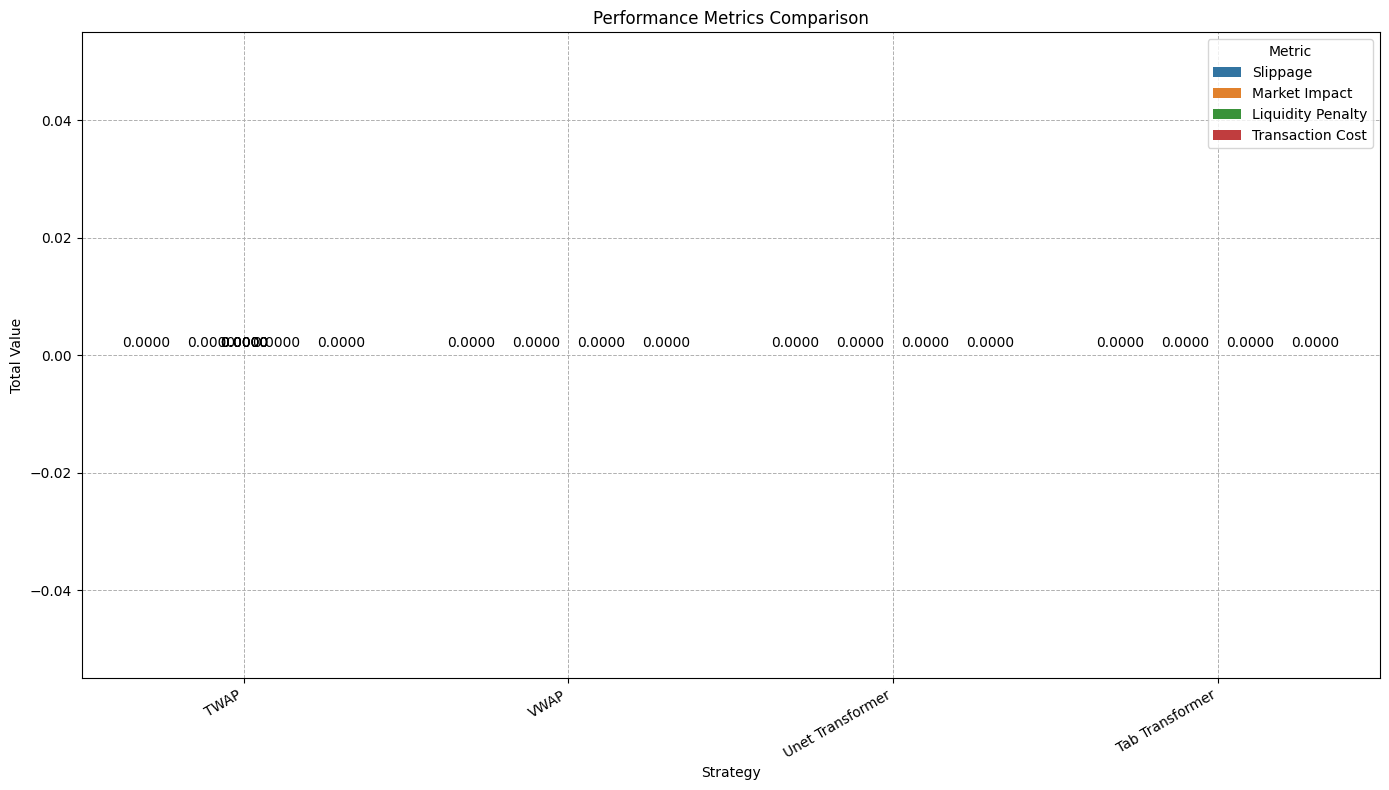

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Reset the DataFrame for easier plotting with Seaborn
metrics_long_df = metrics_df.T.reset_index().melt(id_vars='index', var_name='Metric', value_name='Total Value')

# Plotting with Seaborn
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='index', y='Total Value', hue='Metric', data=metrics_long_df)

# Adding gridlines for better readability
plt.grid(True, which='major', linestyle='--', linewidth=0.7)

# Adding values on the individual bars with four decimal places
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),  # Increased precision to 4 decimal places
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

# Titles and labels
plt.title('Performance Metrics Comparison')
plt.ylabel('Total Value')
plt.xlabel('Strategy')
plt.xticks(rotation=30, ha='right')

# Adjust layout to prevent clipping of labels
plt.tight_layout()

plt.show()